# Overview
The EDA phase will be split into two notebooks due to the complexity of some of the datasets.
This notebook will contain exploratory data analysis of the **Net Overseas Migration** dataset.
The analysis will go through the following phases:
1. Select the states Victoria and New South Wales to focus on for migration and their relation to the housing prices in those states.
2. Statistically and visually, prove the positive correlation between net migration to a state and its median housing prices.
3. Forecast what is likely to happen in the coming years.

# Phase 1
We will select the net migration data over the reference period for the states **Victoria (VIC)** and **New South Wales (NSW)**.
This data will be used in our time series analysis and visualisation.

### Quick rundown of definitions
| Term | Meaning                                            |
| ----- |----------------------------------------------------|
| Arrival | The number of people entering the state/territory  |
| Departure | The number of people leaving the state/territory   |
| Total | The net number of people entering the state/territory (difference between arrival and departure) |

In [8]:
import pandas as pd
migration_data = pd.read_csv('../data/migration_data.csv')
migration_data = migration_data.iloc[:, 1:]
migration_data.head()

,Arrival,Departure,Total,Year,State-Territory
0,75020,-39100,35920,2006,New South Wales
1,51670,-23810,27860,2006,Victoria
2,41240,-21250,19980,2006,Queensland
3,11820,-4640,7180,2006,South Australia
4,26430,-11520,14910,2006,Western Australia


In [9]:
sydney_migration = migration_data.loc[migration_data['State-Territory'] == 'New South Wales'].sort_values('Year')[['Total', 'Year']].reset_index(drop=True)
sydney_migration['Year'] = pd.to_datetime(sydney_migration['Year'], format='%Y')
print(sydney_migration.dtypes)
sydney_migration.head()

Total             int64
Year     datetime64[ns]
dtype: object


,Total,Year
0,35920,2006-01-01
1,76900,2007-01-01
2,96430,2008-01-01
3,70160,2009-01-01
4,50040,2010-01-01


In [10]:
prices_syd = pd.read_excel('../data/median_price_and_number_of_transfers.xlsx', sheet_name=1).iloc[9:, [0, 1]]
prices_syd['Unnamed: 0'] = pd.to_datetime(prices_syd['Unnamed: 0'])
prices_syd.index = prices_syd.iloc[:, 0]
prices_syd.rename_axis('Quarter (Q)', axis='rows', inplace=True)
prices_syd = prices_syd.iloc[:, 1]
prices_syd.name = 'Median Unstratified Housing Prices in Sydney ($\'000)    '
prices_syd

Quarter (Q)
2002-03-01       365
2002-06-01     393.5
2002-09-01       413
2002-12-01       444
2003-03-01     434.5
               ...  
2024-09-01      1410
2024-12-01    1452.5
2025-03-01      1450
2025-06-01      1510
2025-09-01    1464.5
Name: Median Unstratified Housing Prices in Sydney ($'000)    , Length: 95, dtype: object

To visualise the correlation between median house prices and net migration rate in Sydney, we will use both a dual-axis plot to compare the behaviour across time, side by side, as well as using a scatter plot to analyse the correlation using statistics.

In [11]:
# we must first aggregate the quarters in the house prices data so that they match the year-to-year scale of the net migration data
prices_syd_yearly = prices_syd.resample('YS').mean()

# isolate the values that are from 2006 and later, as that lines up with our data for net migration
prices_syd_yearly = prices_syd_yearly[prices_syd_yearly.index.year >= 2006]
prices_syd_yearly

Quarter (Q)
2006-01-01         486.75
2007-01-01        511.575
2008-01-01          490.5
2009-01-01         508.25
2010-01-01        603.375
2011-01-01         566.75
2012-01-01        608.125
2013-01-01          670.0
2014-01-01          738.5
2015-01-01        863.925
2016-01-01        907.625
2017-01-01         989.75
2018-01-01        954.525
2019-01-01          913.0
2020-01-01        961.625
2021-01-01         1229.6
2022-01-01        1318.75
2023-01-01       1348.775
2024-01-01       1429.625
2025-01-01    1474.833333
Freq: YS-JAN, Name: Median Unstratified Housing Prices in Sydney ($'000)    , dtype: object

In [12]:
# print the lengths of both Series now to ensure they are the same length
print('Number of entries for net migration:', len(sydney_migration))
print('Number of entries for median house prices:', len(prices_syd_yearly))

Number of entries for net migration: 20
Number of entries for median house prices: 20


## Actions performed
- [x] Aggregated the quarters of each year and took the mean to denote the average of the median house prices in Sydney from 2006 to 2025.
- [x] Changed the period anchoring to the beginning of the year, rather than the end, in order to match the net migration data's period anchoring.
- [x] Only isolated the data points corresponding to the year 2006 and later to match the time span of the net migration data.
- [x] Ensured that both Series data are the same length to allow for correct plotting on scatter plot.

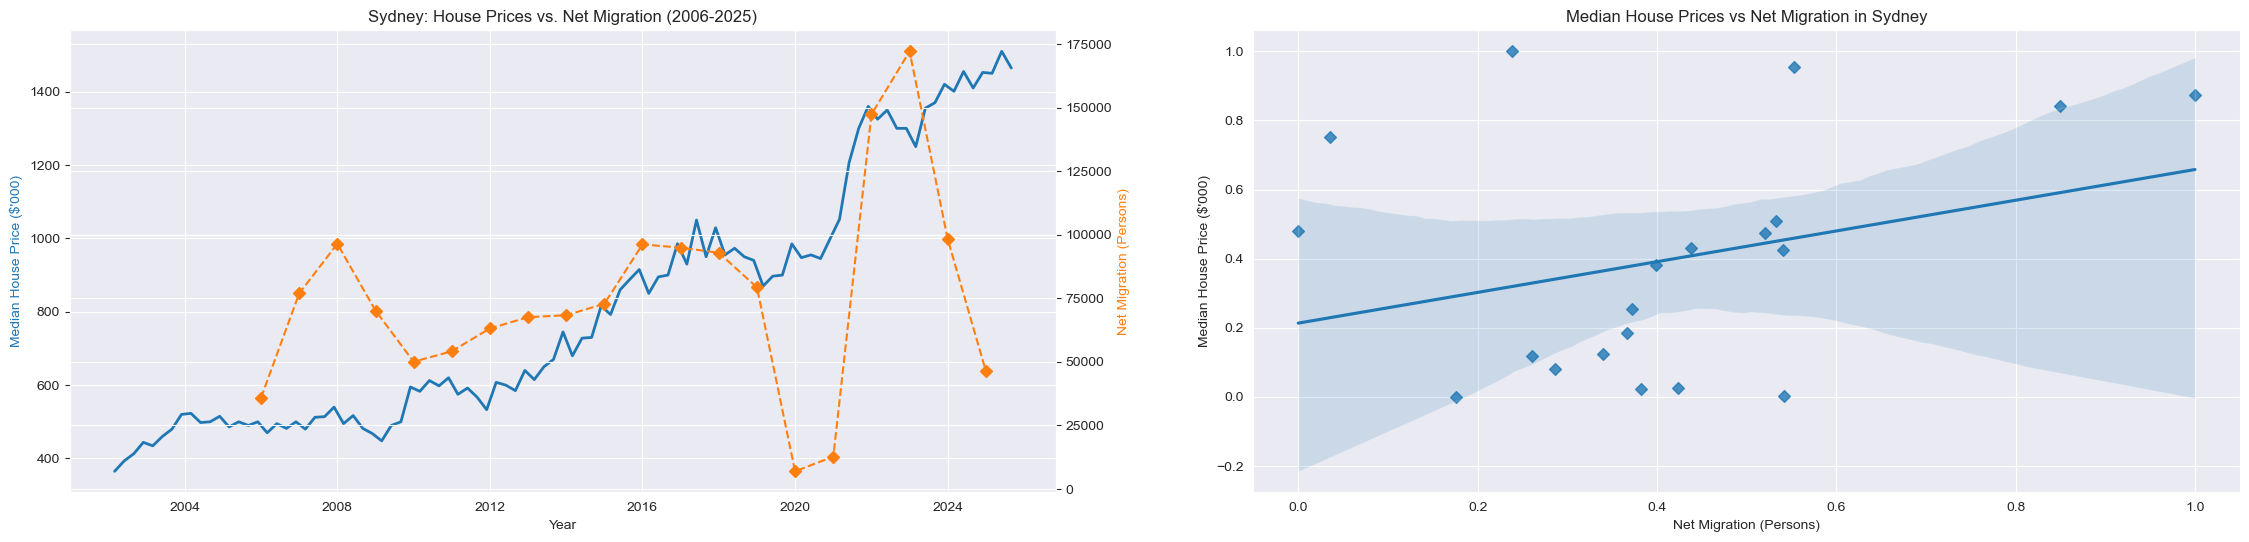

R-squared value: 0.09732481855065722


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(28, 6))

# ======= GRAPH 1 =======
# Plotting House Prices on the Left Axis
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median House Price ($\'000)', color='tab:blue')
axes[0].plot(prices_syd.index, prices_syd, color='tab:blue', linewidth=2)

# Creating the second axis for Migration
ax2 = axes[0].twinx()
ax2.set_ylabel('Net Migration (Persons)', color='tab:orange')
ax2.plot(sydney_migration['Year'], sydney_migration['Total'], color='tab:orange', linestyle='--', marker='D')

# ======= GRAPH 2 =======
# we need to scale the two features as they are of vastly different scales at the moment. A standard min-max scaler will put all values between 0 and 1, allowing for more accurate visualisation of the correlations.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
axes[1].set_xlabel('Net Migration (Persons)')
axes[1].set_ylabel('Median House Price ($\'000)')
axes[1].set_title('Median House Prices vs Net Migration in Sydney')
sns.regplot(x=scaler.fit_transform(sydney_migration['Total'].values.reshape(-1, 1)), y=scaler.fit_transform(prices_syd_yearly.values.reshape(-1, 1)), color='tab:blue', marker='D', ax=axes[1])
plt.title('Sydney: House Prices vs. Net Migration (2006-2025)')
plt.show()

# Calculating the R-squared value for the scatter plot to determine the statistical correlation
from sklearn.linear_model import LinearRegression
x=scaler.fit_transform(sydney_migration['Total'].values.reshape(-1, 1))
y=scaler.fit_transform(prices_syd_yearly.values.reshape(-1, 1))
model = LinearRegression()
model.fit(x, y)
r2 = model.score(x, y)
print('R-squared value:', r2)

## Key Takeaways
1. Housing prices have risen steadily over the last 20 years. This is likely simply due to Australia's chronic issue with housing supply shortages.
2. Net migration dropped steeply in 2020 and stayed low going into 2021. This is most likely due to the COVID-19 pandemic and the lockdowns that had occurred across Australia in this time period.
3. After borders had reopened, net migration skyrocketed to all-time highs due to the backlog of migrants (skilled workers, international students, temporary visa holders) waiting to enter the country.
4. This likely caused an extreme demand shock in the housing market where there was extra competition for buying houses
5. It is known that in the housing industry, it takes some time (1-3 years) for demand shocks to come into full effect for housing prices. For these reasons, Sydney's housing prices have continued to rise heading into 2025.
6. It must also be noted that net migration is not the sole reason for increasing house prices. Australia's **long standing housing supply shorage**, which has existed even prior to the pandemic, is a significant reason why housing prices are still rising. More will be discussed on this later.

# Phase 2
In this phase, we will analyse the housing supply shortages, using **Value of residential building work done** and **Value of residential building work commenced** as proxies for Australia's housing supply.

In [14]:
work_done = pd.read_excel('../data/value_of_residential_building_work_done.xlsx', sheet_name=1)
work_commenced = pd.read_excel('../data/value_of_residential_building_work_commenced.xlsx', sheet_name=1)
work_done

,Unnamed: 0,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Houses ;,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Houses ;.1,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Other Residential ;,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Other Residential ;.1,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; New ; Total Residential ;.1,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; Alterations and additions including conversions ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; Alterations and additions including conversions ; Total Residential ;.1,Value of work done during quarter ; Chain Volume Measures ; New South Wales ; Total (Type of Work) ; Total Residential ;,...,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Houses ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Houses ;.1,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Other Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Other Residential ;.1,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; New ; Total Residential ;.1,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; Alterations and additions including conversions ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; Alterations and additions including conversions ; Total Residential ;.1,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; Total (Type of Work) ; Total Residential ;,Value of work done during quarter ; Chain Volume Measures ; Australian Capital Territory ; Total (Type of Work) ; Total Residential ;.1
0,Unit,$'000,$'000,$'000,$'000,$'000,$'000,$'000,$'000,$'000,...,$'000,$'000,$'000,$'000,$'000,$'000,$'000,$'000,$'000,$'000
1,Series Type,Original,Seasonally Adjusted,Original,Seasonally Adjusted,Original,Seasonally Adjusted,Original,Seasonally Adjusted,Original,...,Original,Seasonally Adjusted,Original,Seasonally Adjusted,Original,Seasonally Adjusted,Original,Seasonally Adjusted,Original,Seasonally Adjusted
2,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,...,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW
3,Frequency,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,...,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter
4,Collection Month,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,2024-09-01 00:00:00,3257180,3180905,3166233,3058919,6423413,6239825,1201286,1143643,7624699,...,141453,139139,328337,315971,469790,455111,36370,34662,506159,489773
210,2024-12-01 00:00:00,3313194,3276988,3140204,3184602,6453399,6461590,1246500,1161789,7699898,...,134643,131678,310184,301694,444827,433372,38898,34570,483726,467942
211,2025-03-01 00:00:00,3021398,3155434,3070441,3226162,6091839,6381595,1078040,1214053,7169879,...,119902,125913,262842,297961,382744,423875,39734,45831,422477,469706
212,2025-06-01 00:00:00,3114839,3093271,3336913,3244094,6451751,6337366,1204814,1211157,7656565,...,125688,124874,347105,332842,472793,457716,43393,43336,516186,501052
